# Getting Started — S&P 500 Data Exploration

Dataset focus: **next trading day’s open vs today’s adjusted close** — we summarize and plot the one-step log return `log(open[t+1] / adj_close[t])`, plus cutoff behavior on the underlying Yahoo `^GSPC` bars.

In [51]:
import os
import sys
from datetime import datetime
from pathlib import Path


def _bootstrap_sys_path() -> Path:
    """Find repo root without importing ``aieng`` (system kernels often lack it)."""
    if os.environ.get("AIENG_REPO_ROOT"):
        root = Path(os.environ["AIENG_REPO_ROOT"]).expanduser().resolve()
        if (root / "aieng-forecasting").is_dir():
            for sub in (root, root / "aieng-forecasting", root / "implementations"):
                s = str(sub)
                if s not in sys.path:
                    sys.path.insert(0, s)
            return root

    seeds: list[Path] = []
    try:
        from IPython import get_ipython  # type: ignore[import-not-found]

        ip = get_ipython()
        if ip is not None:
            nb = ip.user_ns.get("__vsc_ipynb_file__")
            if nb:
                seeds.append(Path(nb).resolve().parent)
    except Exception:
        pass
    for env_key in ("PWD", "INIT_CWD", "OLDPWD"):
        v = os.environ.get(env_key)
        if v:
            try:
                seeds.append(Path(v).expanduser().resolve())
            except (OSError, ValueError):
                pass
    try:
        seeds.append(Path.cwd().resolve())
    except (FileNotFoundError, OSError):
        pass

    for seed in seeds:
        for p in (seed, *seed.parents):
            if (p / "aieng-forecasting").is_dir() and (p / "implementations").is_dir():
                for sub in (p, p / "aieng-forecasting", p / "implementations"):
                    s = str(sub)
                    if s not in sys.path:
                        sys.path.insert(0, s)
                return p

    raise RuntimeError(
        "Cannot find repo root. Pick the project's .venv kernel, or set AIENG_REPO_ROOT."
    )


REPO_ROOT = _bootstrap_sys_path()


import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from experiments.stock_price_forecasting_single_variable.analysis import (
    build_next_day_targets,
    summarize_log_returns,
)
from experiments.stock_price_forecasting_single_variable.data import (
    SP500_SERIES_ID,
    build_sp500_service,
)
from experiments.stock_price_forecasting_single_variable.plots import (
    plot_log_return_distribution,
    plot_price_and_returns,
)


## 1. Build DataService

In [58]:
svc = build_sp500_service(refresh=False, start="1990-01-01")
print("Registered:", svc.series_ids)

Registered: ['sp500_close_adj_usd']


## 2. Summary

In [59]:
summary = svc.summary()
summary["start"] = summary["start"].dt.strftime("%Y-%m-%d")
summary["end"] = summary["end"].dt.strftime("%Y-%m-%d")
summary

,series_id,description,source,units,frequency,n_obs,start,end
0,sp500_close_adj_usd,S&P 500 adjusted close and same-day open (Yaho...,Yahoo Finance (^GSPC),USD,B,9145,1990-01-02,2026-04-24


## 3. Cutoff

In [54]:
cutoff = datetime(2010, 1, 5)
df_cutoff = svc.get_series(SP500_SERIES_ID, as_of=cutoff)
print(len(df_cutoff), df_cutoff["timestamp"].max())
df_cutoff.tail()

5044 2010-01-04 00:00:00


,timestamp,value,released_at,open
5039,2009-12-28,1127.780029,2009-12-29,1127.530029
5040,2009-12-29,1126.199951,2009-12-30,1128.550049
5041,2009-12-30,1126.420044,2009-12-31,1125.530029
5042,2009-12-31,1115.099976,2010-01-01,1126.599976
5043,2010-01-04,1132.989990,2010-01-05,1116.560059


## 4. Open, adjusted close, and target return (next open / today’s close)

Top panel: **open** and **adjusted close** for each session. Bottom panel: `log(open_next / adj_close_today)` vs date (return row keyed to the **next** session, same as backtest target `sp500_log_ret_1b`).

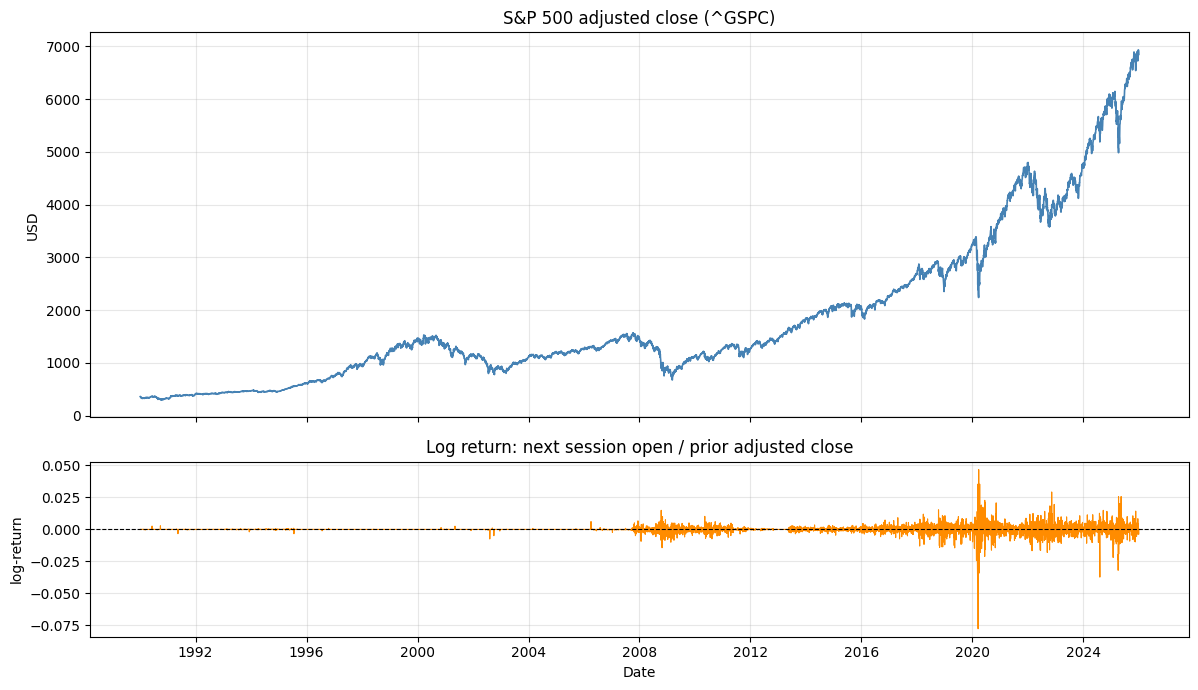

In [55]:
AS_OF = pd.Timestamp("2026-01-02")
df = svc.get_series(SP500_SERIES_ID, as_of=AS_OF).sort_values("timestamp").reset_index(drop=True)
fig, _ = plot_price_and_returns(df)
plt.show()

## 5. Supervised dataset (today’s close → next day open)

Each row in `target_df` is keyed by the **next** session’s `timestamp` (the day whose **open** appears in the ratio). `close_t` is **today’s** adjusted close; `open_t_plus_1b` is the **next** session’s open. `log_ret_1b` is `log(open_next / close_today)`.

Below we also print a few raw Yahoo rows: same `timestamp` carries that day’s `open` and end-of-day adjusted close in `value`.

In [56]:
print("Raw bars (one row per session; value = adj. close that day, open = that session's open):")
display(
    df[["timestamp", "value", "open"]]
    .rename(columns={"value": "adj_close_same_day"})
    .tail(5)
)

print(summarize_log_returns(df))
target_df = build_next_day_targets(df)
dataset_view = target_df.rename(
    columns={
        "close_t": "adj_close_today",
        "open_t_plus_1b": "open_next_trading_day",
        "log_ret_1b": "log_open_next_over_close_today",
    }
)
print("Supervised pairs (timestamp = next session / open day):")
dataset_view.tail()

Raw bars (one row per session; value = adj. close that day, open = that session's open):


,timestamp,adj_close_same_day,open
9062,2025-12-24,6932.049805,6904.910156
9063,2025-12-26,6929.939941,6936.020020
9064,2025-12-29,6905.740234,6903.600098
9065,2025-12-30,6896.240234,6900.439941
9066,2025-12-31,6845.500000,6898.819824


n_obs                           9066.000000
mean_log_ret_1b                    0.000081
std_log_ret_1b                     0.002963
min_log_ret_1b                    -0.077604
max_log_ret_1b                     0.046732
pct_negative_log_return_days       0.282594
dtype: float64
Supervised pairs (timestamp = next session / open day):


,timestamp,adj_close_today,open_next_trading_day,log_open_next_over_close_today
9061,2025-12-24,6909.790039,6904.910156,-0.000706
9062,2025-12-26,6932.049805,6936.020020,0.000573
9063,2025-12-29,6929.939941,6903.600098,-0.003808
9064,2025-12-30,6905.740234,6900.439941,-0.000768
9065,2025-12-31,6896.240234,6898.819824,0.000374


## 6. Distribution

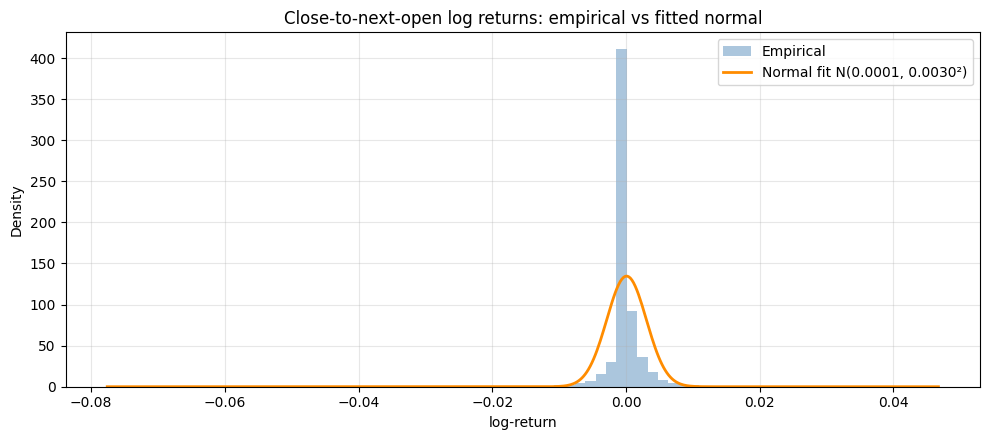

In [57]:
fig, _ = plot_log_return_distribution(df)
plt.show()